In [7]:
import numpy as np
import matplotlib.pyplot as plt

# DADES
tt = 6
t22 = 2
t33 = 3

theta = np.array([10, 35, 25, 10], dtype=float)

ddtheta_max = 50

# Temps
td12 = t22
td23 = t33 - t22
td34 = tt - t33

t_ = np.arange(0, tt + 0.01, 0.01)

# TRAJECTÒRIA IDEAL
theta_ideal_ = np.zeros_like(t_)

for i, t in enumerate(t_):
    if t <= t22:
        theta_ideal_[i] = theta[0] + (theta[1]-theta[0])/td12 * t
    elif t <= t33:
        theta_ideal_[i] = theta[1] + (theta[2]-theta[1])/td23 * (t - t22)
    else:
        theta_ideal_[i] = theta[2] + (theta[3]-theta[2])/td34 * (t - t33)

# --- TRAMS ---

ddtheta = np.zeros(4)
t = np.zeros(4)

# Tram 1
if theta[1] - theta[0] == 0:
    ddtheta[0] = 0
    t[0] = 0
else:
    ddtheta[0] = np.sign(theta[1] - theta[0]) * ddtheta_max
    t[0] = td12 - np.sqrt(td12**2 - 2*(theta[1]-theta[0])/ddtheta[0])

dtheta12 = (theta[1]-theta[0])/(td12 - 0.5*t[0])

# Tram 4
if theta[2] - theta[3] == 0:
    ddtheta[3] = 0
    t[3] = 0
else:
    ddtheta[3] = np.sign(theta[2]-theta[3]) * ddtheta_max
    t[3] = td34 - np.sqrt(td34**2 + 2*(theta[3]-theta[2])/ddtheta[3])

dtheta34 = (theta[3]-theta[2])/(td34 - 0.5*t[3])

# Tram central
dtheta23 = (theta[2]-theta[1]) / td23

# Acceleracions intermèdies
if dtheta23 - dtheta12 == 0:
    ddtheta[1] = 0
    t[1] = 0
else:
    ddtheta[1] = np.sign(dtheta23 - dtheta12) * ddtheta_max
    t[1] = (dtheta23 - dtheta12) / ddtheta[1]

if dtheta34 - dtheta23 == 0:
    ddtheta[2] = 0
    t[2] = 0
else:
    ddtheta[2] = np.sign(dtheta34 - dtheta23) * ddtheta_max
    t[2] = (dtheta34 - dtheta23) / ddtheta[2]

# Intervals
t12 = td12 - t[0] - 0.5*t[1]
t23 = td23 - 0.5*(t[1] + t[2])
t34 = td34 - t[3] - 0.5*t[2]

# Posicions parcials
thetai = np.zeros(4)
thetai[0] = 0.5*ddtheta[0]*t[0]**2
thetai[1] = dtheta12*t[1] + 0.5*ddtheta[1]*t[1]**2
thetai[2] = dtheta23*t[2] + 0.5*ddtheta[2]*t[2]**2
thetai[3] = dtheta34*t[3] + 0.5*ddtheta[3]*t[3]**2

theta12 = dtheta12*t12
theta23 = dtheta23*t23
theta34 = dtheta34*t34

# Temps acumulats
t_a = np.zeros(7)
t_a[0] = t[0]
t_a[1] = t_a[0] + t12
t_a[2] = t_a[1] + t[1]
t_a[3] = t_a[2] + t23
t_a[4] = t_a[3] + t[2]
t_a[5] = t_a[4] + t34
t_a[6] = t_a[5] + t[3]

# Posicions acumulades
theta_a = np.zeros(7)
theta_a[0] = theta[0] + thetai[0]
theta_a[1] = theta_a[0] + theta12
theta_a[2] = theta_a[1] + thetai[1]
theta_a[3] = theta_a[2] + theta23
theta_a[4] = theta_a[3] + thetai[2]
theta_a[5] = theta_a[4] + theta34
theta_a[6] = theta_a[5] + thetai[3]

# RESULTATS
theta_ = np.zeros_like(t_)
dtheta_ = np.zeros_like(t_)
ddtheta_ = np.zeros_like(t_)

for i, tt_ in enumerate(t_):
    if tt_ <= t_a[0]:
        theta_[i] = theta[0] + 0.5*ddtheta[0]*tt_**2
        dtheta_[i] = ddtheta[0]*tt_
        ddtheta_[i] = ddtheta[0]

    elif tt_ <= t_a[1]:
        theta_[i] = theta_a[0] + dtheta12*(tt_ - t_a[0])
        dtheta_[i] = dtheta12

    elif tt_ <= t_a[2]:
        dt = tt_ - t_a[1]
        theta_[i] = theta_a[1] + dtheta12*dt + 0.5*ddtheta[1]*dt**2
        dtheta_[i] = dtheta12 + ddtheta[1]*dt
        ddtheta_[i] = ddtheta[1]

    elif tt_ <= t_a[3]:
        theta_[i] = theta_a[2] + dtheta23*(tt_ - t_a[2])
        dtheta_[i] = dtheta23

    elif tt_ <= t_a[4]:
        dt = tt_ - t_a[3]
        theta_[i] = theta_a[3] + dtheta23*dt + 0.5*ddtheta[2]*dt**2
        dtheta_[i] = dtheta23 + ddtheta[2]*dt
        ddtheta_[i] = ddtheta[2]

    elif tt_ <= t_a[5]:
        theta_[i] = theta_a[4] + dtheta34*(tt_ - t_a[4])
        dtheta_[i] = dtheta34

    else:
        dt = tt_ - t_a[5]
        theta_[i] = theta_a[5] + dtheta34*dt + 0.5*ddtheta[3]*dt**2
        dtheta_[i] = dtheta34 + ddtheta[3]*dt
        ddtheta_[i] = ddtheta[3]




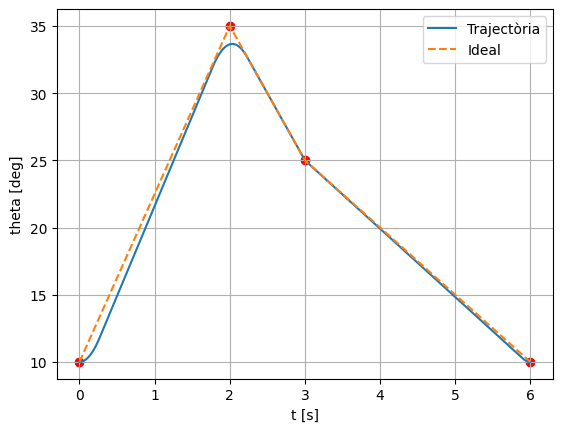

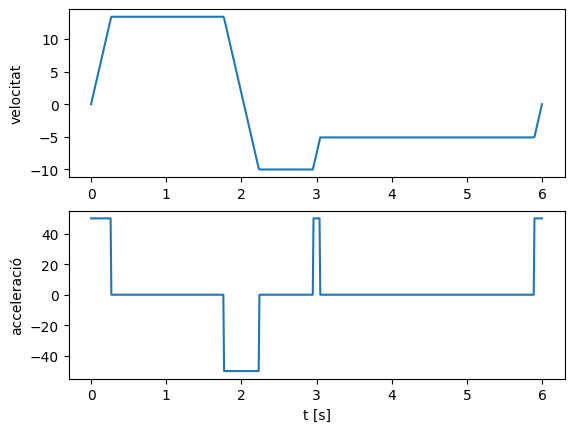

In [8]:
# PLOTS
plt.figure()
plt.plot(t_, theta_, label='Trajectòria')
plt.plot(t_, theta_ideal_, '--', label='Ideal')
plt.scatter([0, t22, t33, tt], theta, color='red')
plt.xlabel('t [s]')
plt.ylabel('theta [deg]')
plt.legend()
plt.grid()

plt.figure()
plt.subplot(2,1,1)
plt.plot(t_, dtheta_)
plt.ylabel('velocitat')

plt.subplot(2,1,2)
plt.plot(t_, ddtheta_)
plt.ylabel('acceleració')
plt.xlabel('t [s]')

plt.show()